# 🫁 Curated Chest X-Ray Image Dataset for COVID-19

**Architecture Overview:**
- **Branch 1:** ShuffleNetV2 + ECA (Efficient Channel Attention) — lightweight, fine-grained local features
- **Branch 2:** EfficientNet-B0 + CBAM (Convolutional Block Attention Module) — global semantic + spatial features
- **LAMR Module:** Lesion-Aware Multi-scale Refinement (inspired by multi-scale nodule detection)
- **Grad-CAM:** Interpretability visualization for clinical reliability

> Dataset: https://www.kaggle.com/datasets/unaissait/curated-chest-xray-ima
ge-dataset-for-covid19

## 1. Install & Import Dependencies

In [1]:
# ── Install / pin compatible package versions ─────────────────────────────────
# Colab pre-installs numpy/scipy. Installing timm/albumentations/grad-cam on top
# without pinning can upgrade numpy to a version scipy's compiled binaries don't
# match, causing errors like:
#   AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'
# Fix: pin a known-compatible numpy/scipy/seaborn combo, then restart the runtime
# ONCE so the freshly installed binaries are actually loaded (a plain pip install
# does not swap out an already-imported C extension in the live process).
import os, sys, subprocess

def pip_install(pkg, force_reinstall=False):
    command = [sys.executable, '-m', 'pip', 'install', '-q', pkg]
    if force_reinstall:
        command.append('--force-reinstall')
    subprocess.check_call(command)

_RESTART_FLAG = '/content/.deps_installed_v1'

if not os.path.exists(_RESTART_FLAG):
    print('Installing / pinning compatible package versions (first run)...')
    pip_install('numpy==1.26.4', force_reinstall=True)
    pip_install('scipy==1.13.1', force_reinstall=True)
    pip_install('pandas==2.2.2', force_reinstall=True)
    pip_install('seaborn==0.13.2', force_reinstall=True)
    pip_install('timm', force_reinstall=True)
    pip_install('grad-cam')
    pip_install('albumentations')
    pip_install('torchinfo')

    with open(_RESTART_FLAG, 'w') as f:
        f.write('done')

    print('\n✅ Packages installed.')
    print('🔄 Restarting the Colab runtime automatically so the new versions load cleanly...')
    print('   Colab will show "Your session crashed" — that is expected.')
    print('   Just click "Run all" again; installation will be skipped the 2nd time.')
    os.kill(os.getpid(), 9)
else:
    print('Dependencies already installed in this session — skipping install step.')


Dependencies already installed in this session — skipping install step.


In [2]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as tv_models
import timm

# ── Sklearn metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Albumentations ────────────────────────────────────────────────────────────
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Output directory (Colab has no /kaggle/working — use a local folder instead) ──
OUTPUT_DIR = Path('/content/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cuda


## 2. Configuration

In [3]:
import os, shutil
from pathlib import Path
import subprocess # Added for pip_install and kaggle commands

# Function to install packages
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Ensure kaggle is installed for downloading datasets
pip_install('kaggle')

# ── Kaggle dataset download setup ───────────────────────────────────────────
# Go to Kaggle -> Your Profile -> Account -> Create New API Token (downloads
# kaggle.json), then upload it to this Colab session's /content/ folder.
print("Setting up Kaggle API credentials...")
kaggle_json_path = Path('/root/.kaggle/kaggle.json')
kaggle_json_path.parent.mkdir(exist_ok=True, parents=True)
if Path('/content/kaggle.json').exists():
    !mv /content/kaggle.json {kaggle_json_path}
    !chmod 600 {kaggle_json_path}
    print("Kaggle API credentials set.")
elif kaggle_json_path.exists():
    print("Kaggle API credentials already set from a previous run.")
else:
    print("WARNING: kaggle.json not found in /content/. Please upload your Kaggle API key.")
    print("Download it from Kaggle -> Your Profile -> Account -> Create New API Token.")
    print("Then upload the kaggle.json file to your Colab session's files (e.g., via File -> Upload).")

# ── Hyper-parameters & paths ─────────────────────────────────────────────────
class CFG:
    KAGGLE_DATASET_ID = 'unaissait/curated-chest-xray-image-dataset-for-covid19'
    DOWNLOAD_DIR      = Path('./kaggle_data')  # Directory to download data into
    DATA_DIR          = DOWNLOAD_DIR           # kept for compatibility; not relied on directly

    # ── Image ─────────────────────────────────────────────────────────────────
    IMG_SIZE   = 224
    IN_CHANS   = 3

    # ── Training ──────────────────────────────────────────────────────────────
    BATCH_SIZE = 32
    EPOCHS      = 15
    LR         = 3e-4
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 4

    # ── Model — CLASSES/NUM_CLASSES are placeholders, overwritten below once
    #    the real class folders are discovered on disk ─────────────────────────
    NUM_CLASSES   = 0
    FUSION_DIM    = 256
    LAMR_CHANNELS = 256
    CLASSES       = []

    # ── Checkpoint (Colab-safe path — /kaggle/working does not exist here) ────
    CKPT_PATH = str(OUTPUT_DIR / 'best_model.pth')

cfg = CFG()
print('Configuration loaded.')

IMG_EXTS = {'.jpg', '.jpeg', '.png'}

def discover_classes(root: Path):
    """
    Scan `root` recursively and group image files by the folder that directly
    contains them. Generic wrapper folder names (e.g. 'images') are skipped in
    favor of their parent, since some Kaggle zips nest an extra 'images'
    sub-folder inside each class folder.
    Returns {class_name: directory_path}.
    """
    generic_names = {'images', 'image', 'img', 'imgs', 'data'}
    class_dirs = {}
    if not root.exists():
        return class_dirs
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            parent = p.parent
            if parent.name.lower() in generic_names and parent.parent != root:
                parent = parent.parent
            class_dirs.setdefault(parent.name, parent)
    return class_dirs

def download_dataset():
    print(f"Downloading Kaggle dataset '{cfg.KAGGLE_DATASET_ID}' to '{cfg.DOWNLOAD_DIR}'...")
    cfg.DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    !kaggle datasets download -d {cfg.KAGGLE_DATASET_ID} -p {cfg.DOWNLOAD_DIR} --unzip
    print("Dataset download and extraction complete.")

# ── Download if missing, then verify it actually contains images ─────────────
if not cfg.DOWNLOAD_DIR.exists() or not any(cfg.DOWNLOAD_DIR.iterdir()):
    download_dataset()
else:
    print(f"'{cfg.DOWNLOAD_DIR}' already exists — checking whether it's a complete download...")

CLASS_DIRS = discover_classes(cfg.DOWNLOAD_DIR)

# If nothing usable was found, the existing folder is likely a broken/partial
# download from an earlier crashed run — wipe it and re-download once.
if not CLASS_DIRS:
    print(f"⚠️  No image class folders found under '{cfg.DOWNLOAD_DIR}' — it looks incomplete/broken.")
    print("   Removing it and re-downloading fresh...")
    shutil.rmtree(cfg.DOWNLOAD_DIR, ignore_errors=True)
    download_dataset()
    CLASS_DIRS = discover_classes(cfg.DOWNLOAD_DIR)

if not CLASS_DIRS:
    print(f"\n❌ Still no image folders found under '{cfg.DOWNLOAD_DIR}' after a fresh download.")
    print("   Full directory tree for manual inspection:")
    for item in sorted(cfg.DOWNLOAD_DIR.rglob('*')):
        marker = '/' if item.is_dir() else ''
        print(f'    {item}{marker}')
    raise RuntimeError(
        "Could not auto-discover class folders. Check the tree printed above and "
        "tell me the real folder names so I can adjust the loader."
    )
else:
    cfg.CLASSES = sorted(CLASS_DIRS.keys())
    cfg.NUM_CLASSES = len(cfg.CLASSES)
    print(f"\n✅ Discovered {cfg.NUM_CLASSES} classes:")
    for cls_name in cfg.CLASSES:
        n_imgs = sum(1 for f in CLASS_DIRS[cls_name].rglob('*')
                     if f.is_file() and f.suffix.lower() in IMG_EXTS)
        print(f'    {cls_name:25s} → {CLASS_DIRS[cls_name]}  ({n_imgs} images)')


Setting up Kaggle API credentials...
Download it from Kaggle -> Your Profile -> Account -> Create New API Token.
Then upload the kaggle.json file to your Colab session's files (e.g., via File -> Upload).
Configuration loaded.
Dataset URL: https://www.kaggle.com/datasets/unaissait/curated-chest-xray-image-dataset-for-covid19
License(s): Attribution 4.0 International (CC BY 4.0)


Dataset download and extraction complete.

✅ Discovered 4 classes:
    COVID-19                  → kaggle_data/Curated X-Ray Dataset/COVID-19  (1281 images)
    Normal                    → kaggle_data/Curated X-Ray Dataset/Normal  (3270 images)
    Pneumonia-Bacterial       → kaggle_data/Curated X-Ray Dataset/Pneumonia-Bacterial  (3001 images)
    Pneumonia-Viral           → kaggle_data/Curated X-Ray Dataset/Pneumonia-Viral  (1656 images)


## 3. Dataset & Data Augmentation

In [4]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
# Removed zipfile import as data is already extracted

SEED = 42 # Defined SEED explicitly in this cell

# ── Albumentations pipelines ─────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        # ── Enhancement (mirrors preprocessing in the paper) ──────────────────
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),      # histogram equalization
        A.RandomBrightnessContrast(brightness_limit=0.2,
                                   contrast_limit=0.2, p=0.5),       # contrast stretching
        # ── Augmentation ──────────────────────────────────────────────────────
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=15, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])


# ── Custom Dataset ────────────────────────────────────────────────────────────
class ChestXRayDataset(Dataset):
    """
    Loads images from a list of (image_path, label) tuples.
    """
    def __init__(self, samples, transform=None):
        self.transform = transform
        self.samples   = samples

        print(f'  → Loaded {len(self.samples)} images.')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = np.array(Image.open(img_path).convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


# ── Data Collection and Splitting ───────────────────────────────────────────
print('Collecting and splitting data...')
all_samples = []
label_map = {cls: i for i, cls in enumerate(cfg.CLASSES)}

# Removed EXTRACT_DIR as data is already extracted
# EXTRACT_DIR = Path('/kaggle/working/extracted_images')
# EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

for cls_name in cfg.CLASSES:
    # Use the directory discovered in the config cell (CLASS_DIRS), not a
    # guessed cfg.DATA_DIR / cls_name path — dataset layouts vary.
    class_dir = CLASS_DIRS.get(cls_name)

    if class_dir is None or not class_dir.is_dir():
        print(f'[WARN] Class directory not found for {cls_name!r}. Skipping.')
        continue

    # Removed zip extraction logic as it's no longer needed
    # extract_to_path = EXTRACT_DIR / cls_name
    # extract_to_path.mkdir(parents=True, exist_ok=True)
    # print(f'Extracting {zip_path.name} to {extract_to_path}...')
    # with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    #     zip_ref.extractall(extract_to_path)

    # Now collect images from the extracted directory
    # Use rglob to search recursively, as class folders often contain subfolders (e.g., 'images').
    for img_path in class_dir.rglob('*'):
        if img_path.is_file() and img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            all_samples.append((img_path, label_map[cls_name]))


# Split into train, validation, and test sets
# First, split into train (80%) and temp (20%)
train_samples, temp_samples = train_test_split(
    all_samples, test_size=0.2, stratify=[s[1] for s in all_samples], random_state=SEED
)
# Then, split temp into validation (50% of temp, so 10% of total) and test (50% of temp, so 10% of total)
val_samples, test_samples = train_test_split(
    temp_samples, test_size=0.5, stratify=[s[1] for s in temp_samples], random_state=SEED
)

print(f'Total images found: {len(all_samples)}')
print(f'Train images: {len(train_samples)}')
print(f'Validation images: {len(val_samples)}')
print(f'Test images: {len(test_samples)}')

# ── Build dataloaders ─────────────────────────────────────────────────────────
print('Building datasets...')
train_dataset = ChestXRayDataset(train_samples, transform=get_train_transforms())
val_dataset   = ChestXRayDataset(val_samples,   transform=get_val_transforms())
test_dataset  = ChestXRayDataset(test_samples,  transform=get_val_transforms())

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                          shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE,
                          shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.BATCH_SIZE,
                          shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)

# ── Class distribution ────────────────────────────────────────────────────────
labels_train = [s[1] for s in train_dataset.samples]
unique, counts = np.unique(labels_train, return_counts=True)
print('\nClass distribution (train):')
for u, c in zip(unique, counts):
    print(f'  {cfg.CLASSES[u]}: {c}')

labels_val = [s[1] for s in val_dataset.samples]
unique_val, counts_val = np.unique(labels_val, return_counts=True)
print('\nClass distribution (val):')
for u, c in zip(unique_val, counts_val):
    print(f'  {cfg.CLASSES[u]}: {c}')

labels_test = [s[1] for s in test_dataset.samples]
unique_test, counts_test = np.unique(labels_test, return_counts=True)
print('\nClass distribution (test):')
for u, c in zip(unique_test, counts_test):
    print(f'  {cfg.CLASSES[u]}: {c}')


Total images found: 9208
Train images: 7366
Validation images: 921
Test images: 921
Building datasets...
  → Loaded 7366 images.
  → Loaded 921 images.
  → Loaded 921 images.

Class distribution (train):
  COVID-19: 1025
  Normal: 2616
  Pneumonia-Bacterial: 2400
  Pneumonia-Viral: 1325

Class distribution (val):
  COVID-19: 128
  Normal: 327
  Pneumonia-Bacterial: 300
  Pneumonia-Viral: 166

Class distribution (test):
  COVID-19: 128
  Normal: 327
  Pneumonia-Bacterial: 301
  Pneumonia-Viral: 165


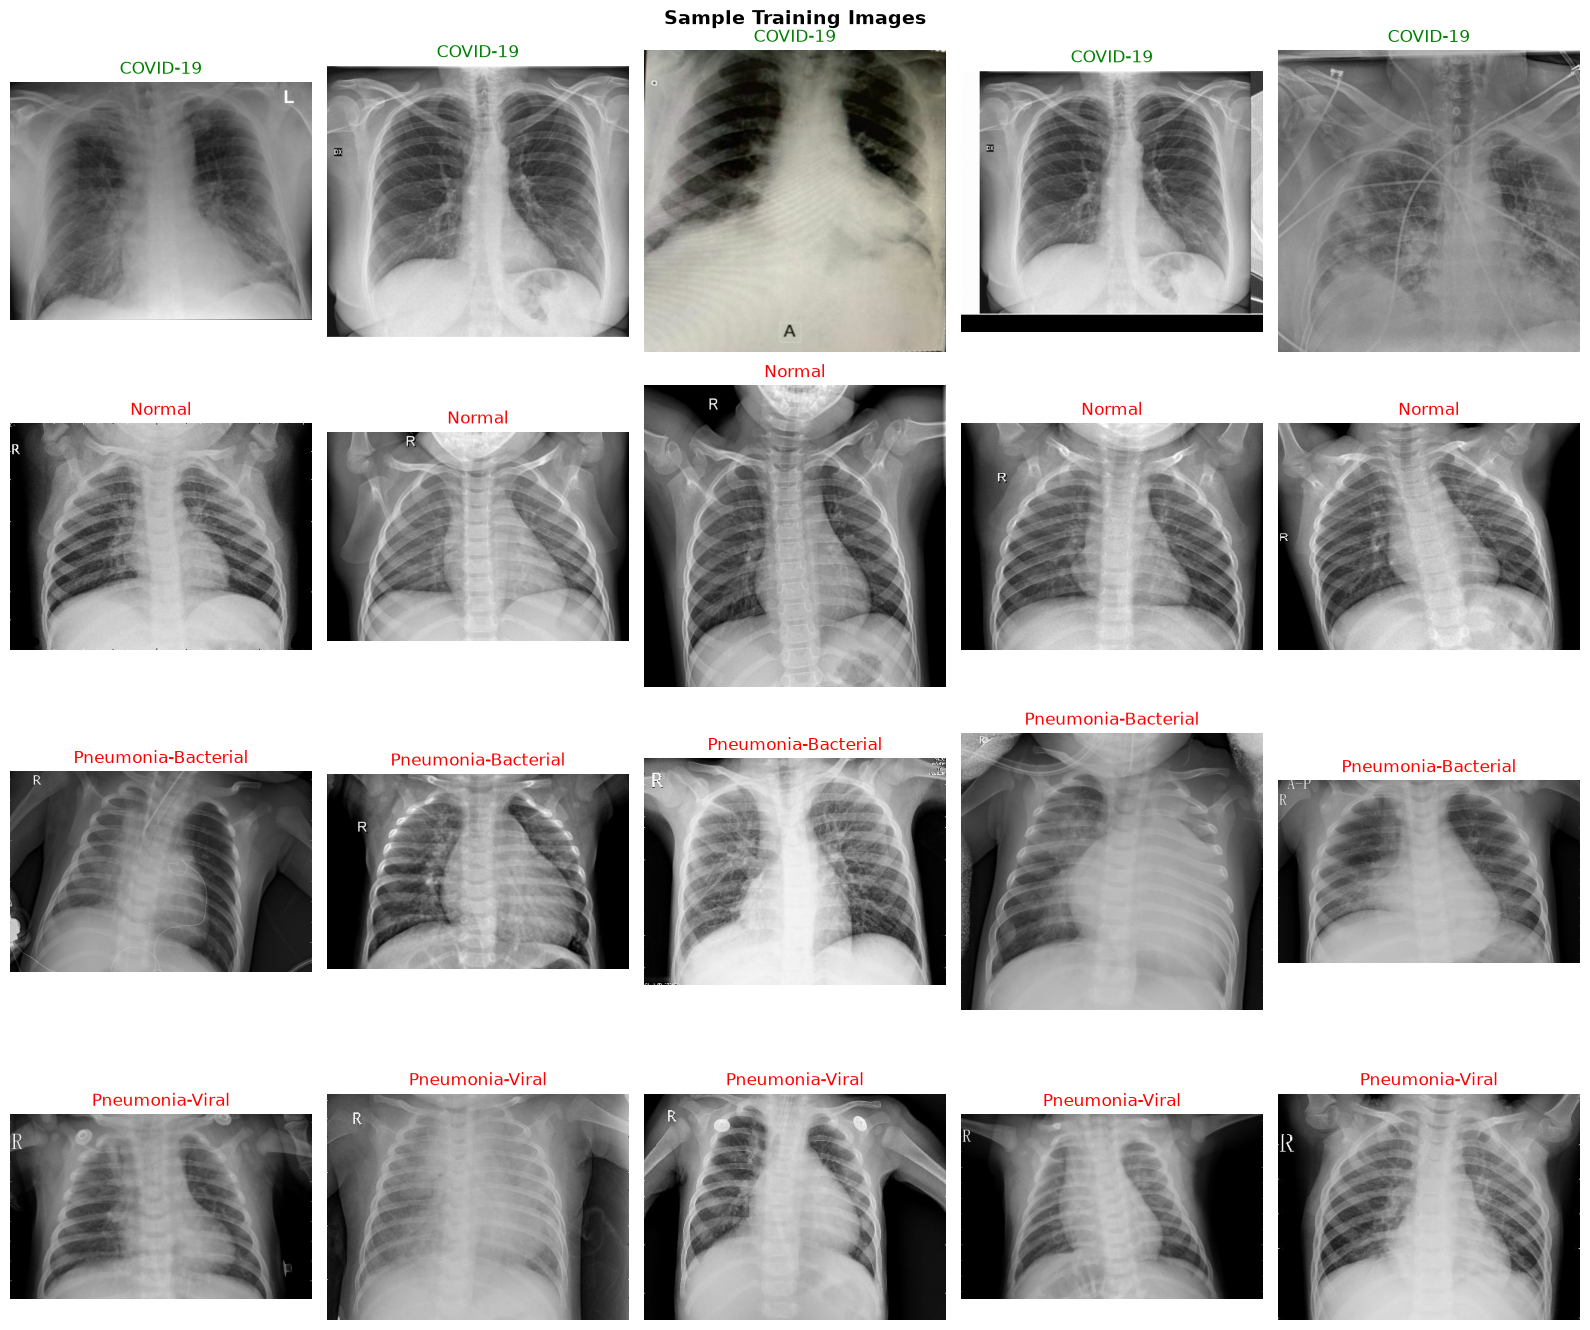

In [5]:
# ── Visualise sample images ───────────────────────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Adjust number of rows for subplots based on the number of classes
# and scale figsize accordingly.
fig, axes = plt.subplots(len(cfg.CLASSES), 5, figsize=(16, len(cfg.CLASSES) * 3.5))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(cfg.CLASSES):
    cls_samples = [(p, l) for p, l in train_dataset.samples if l == cls_idx]
    for i in range(5):
        img_path, _ = random.choice(cls_samples)
        img = np.array(Image.open(img_path).convert('RGB'))
        axes[cls_idx, i].imshow(img, cmap='gray' if img.mean(axis=2).std() < 10 else None)
        axes[cls_idx, i].set_title(cls_name, color='green' if cls_idx == 0 else 'red')
        axes[cls_idx, i].axis('off')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'sample_images.png'), dpi=150)
plt.show()

## 4. Attention Modules: ECA, CBAM

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  ECA — Efficient Channel Attention                                          ║
# ║  Wang et al. (2020) CVPR                                                    ║
# ║  Replaces FC bottleneck with a lightweight 1-D convolution across channels  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class ECA(nn.Module):
    """
    Efficient Channel Attention.
    Kernel size k is adaptively determined from the number of channels C.
    """
    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        # Adaptive kernel size
        t  = int(abs(math.log2(channels) / gamma + b / gamma))
        k  = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k,
                                  padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        y = self.avg_pool(x)            # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(-1, -2)  # (B, 1, C)
        y = self.conv(y)                # (B, 1, C)
        y = y.transpose(-1, -2).unsqueeze(-1)  # (B, C, 1, 1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CBAM — Convolutional Block Attention Module                                ║
# ║  Woo et al. (2018) ECCV                                                     ║
# ║  Sequential channel attention → spatial attention                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        out     = self.sigmoid(avg_out + max_out)
        return x * out.unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True).values
        out     = torch.cat([avg_out, max_out], dim=1)
        out     = self.sigmoid(self.conv(out))
        return x * out


class CBAM(nn.Module):
    """Channel → Spatial attention block."""
    def __init__(self, channels: int, reduction: int = 16, spatial_k: int = 7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(spatial_k)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ca(x)
        x = self.sa(x)
        return x


print('ECA and CBAM modules defined.')

ECA and CBAM modules defined.


## 5. LAMR — Lesion-Aware Multi-scale Refinement Module

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  LAMR — Lesion-Aware Multi-scale Refinement                                 ║
# ║                                                                              ║
# ║  Inspired by the HPFF (Hierarchical Progressive Feature Fusion) and GCSAM   ║
# ║  ideas in Li et al. (2025) for lung nodule detection.                        ║
# ║                                                                              ║
# ║  Three parallel convolution streams (1×1, 3×3, 5×5) capture lesion          ║
# ║  patterns at different receptive fields, then a channel-wise                 ║
# ║  attention gate produces a lesion-sensitive mask to refine the fused         ║
# ║  feature map.                                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class LAMRBlock(nn.Module):
    """
    Lesion-Aware Multi-scale Refinement block.

    Args:
        in_channels  : number of input channels (= fusion feature size after projection)
        out_channels : number of output channels
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        mid = out_channels // 4  # internal bottleneck

        # ── Multi-scale parallel branches ──────────────────────────────────────
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch5 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # ── Global context (avg-pool) branch ───────────────────────────────────
        self.branch_global = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )

        concat_ch = mid * 4          # 4 branches

        # ── Projection to out_channels ─────────────────────────────────────────
        self.proj = nn.Sequential(
            nn.Conv2d(concat_ch, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )

        # ── Lesion-sensitive attention gate (channel-wise) ─────────────────────
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

        # ── Residual shortcut (adjust channels if needed) ──────────────────────
        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape

        b1 = self.branch1(x)                     # (B, mid, H, W)
        b3 = self.branch3(x)                     # (B, mid, H, W)
        b5 = self.branch5(x)                     # (B, mid, H, W)
        bg = self.branch_global(x).expand(B, -1, H, W)  # broadcast

        ms = torch.cat([b1, b3, b5, bg], dim=1)  # (B, 4*mid, H, W)
        ms = self.proj(ms)                        # (B, out_channels, H, W)

        # ── Apply lesion attention gate ────────────────────────────────────────
        gate_w = self.gate(ms)                    # (B, out_channels, 1, 1)
        ms     = ms * gate_w                      # element-wise scale

        return ms + self.shortcut(x)              # residual addition


print('LAMR block defined.')

LAMR block defined.


## 6. Branch Backbones: ShuffleNetV2 + ECA and EfficientNet-B0 + CBAM

In [8]:
class ShuffleNetV2_ECA(nn.Module):
    def __init__(self, proj_dim: int = 256, pretrained: bool = True):
        super().__init__()
        weights = tv_models.ShuffleNet_V2_X1_0_Weights.DEFAULT if pretrained else None
        base = tv_models.shufflenet_v2_x1_0(weights=weights)

        # Drop the final fc layer; keep everything else (conv1, maxpool, stages, conv5)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        feat_dim = base.fc.in_features  # 1024 for x1.0

        self.eca = ECA(channels=feat_dim)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor):
        feat = self.backbone(x)   # (B, 1024, H', W')
        feat = self.eca(feat)
        feat = self.gap(feat)
        feat = self.proj(feat)
        return feat

    def get_last_conv(self):
        for m in reversed(list(self.backbone.modules())):
            if isinstance(m, nn.Conv2d):
                return m

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  EfficientNet-B0 + CBAM branch                                              ║
# ║  (This class was referenced by HybridPneumoniaNet but was missing from the  ║
# ║   original notebook — added here, mirroring ShuffleNetV2_ECA's structure.)  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class EfficientNetB0_CBAM(nn.Module):
    def __init__(self, proj_dim: int = 256, pretrained: bool = True):
        super().__init__()
        weights = tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        base = tv_models.efficientnet_b0(weights=weights)

        # torchvision's EfficientNet exposes `.features` (the conv backbone)
        # and `.classifier` (final FC); we drop the classifier and keep the
        # conv feature map, same pattern as ShuffleNetV2_ECA above.
        self.backbone = base.features
        feat_dim = base.classifier[1].in_features  # 1280 for EfficientNet-B0

        self.cbam = CBAM(channels=feat_dim)
        self.gap  = nn.AdaptiveAvgPool2d(1)

        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor):
        feat = self.backbone(x)   # (B, 1280, H', W')
        feat = self.cbam(feat)
        feat = self.gap(feat)
        feat = self.proj(feat)
        return feat

    def get_last_conv(self):
        for m in reversed(list(self.backbone.modules())):
            if isinstance(m, nn.Conv2d):
                return m

print('EfficientNetB0_CBAM defined.')


EfficientNetB0_CBAM defined.


In [10]:
import timm
print(f"timm version: {timm.__version__}")

all_models = timm.list_models()
print(f"Total models found by timm: {len(all_models)}")

print("Available ShuffleNet models (case-insensitive search):")
found_shufflenet = False
for model_name in all_models:
    if 'shufflenet' in model_name.lower():
        print(f'- {model_name}')
        found_shufflenet = True

if not found_shufflenet:
    print("No models containing 'shufflenet' were found in timm. This might indicate a problem with the timm installation or that this specific model is not available.")


timm version: 1.0.28
Total models found by timm: 1293
Available ShuffleNet models (case-insensitive search):
No models containing 'shufflenet' were found in timm. This might indicate a problem with the timm installation or that this specific model is not available.


## 7. Full Hybrid Model

In [11]:
class HybridPneumoniaNet(nn.Module):
    """
    Updated Hybrid Framework
    ========================
    Input  → [ShuffleNetV2+ECA] branch  (local, fine-grained)
           → [EfficientNet-B0+CBAM] branch (global, semantic)
    Fused features → spatial reshape → LAMR module → GAP → classifier

    The LAMR module operates on a 2D spatial feature map reconstructed
    from the concatenated 1-D vectors via a learned reshape/expand path,
    mimicking the receptive-field diversity of the HPFF + GCSAM approach.
    """

    def __init__(
        self,
        num_classes  : int = 2,
        proj_dim     : int = 256,
        lamr_channels: int = 256,
        pretrained   : bool = True,
        dropout_p    : float = 0.4
    ):
        super().__init__()

        # ── Two feature branches ──────────────────────────────────────────────
        self.branch_shuffle = ShuffleNetV2_ECA(proj_dim=proj_dim,
                                                pretrained=pretrained)
        self.branch_effnet  = EfficientNetB0_CBAM(proj_dim=proj_dim,
                                                   pretrained=pretrained)

        fused_dim = proj_dim * 2   # concatenation of two branches

        # ── Fusion projection to a square spatial map for LAMR ────────────────
        # We reshape the fused vector to (B, fused_dim, 1, 1) then upsample
        self.fusion_proj = nn.Sequential(
            nn.Linear(fused_dim, lamr_channels),
            nn.BatchNorm1d(lamr_channels),
            nn.ReLU(inplace=True)
        )
        # Upsample 1×1 → 7×7 feature map for LAMR to act on
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(lamr_channels, lamr_channels,
                               kernel_size=7, stride=1, bias=False),
            nn.BatchNorm2d(lamr_channels),
            nn.ReLU(inplace=True)
        )

        # ── LAMR module ───────────────────────────────────────────────────────
        self.lamr = LAMRBlock(in_channels=lamr_channels,
                              out_channels=lamr_channels)

        # ── Global Average Pool + Classifier ─────────────────────────────────
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(lamr_channels, lamr_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p / 2),
            nn.Linear(lamr_channels // 2, num_classes)
        )

    def forward(self, x: torch.Tensor):
        # Branch 1: ShuffleNetV2 + ECA
        f1 = self.branch_shuffle(x)           # (B, proj_dim)
        # Branch 2: EfficientNet-B0 + CBAM
        f2 = self.branch_effnet(x)            # (B, proj_dim)

        # ── Feature fusion ────────────────────────────────────────────────────
        fused = torch.cat([f1, f2], dim=1)    # (B, 2*proj_dim)
        fused = self.fusion_proj(fused)        # (B, lamr_channels)

        # ── Reshape to 2D spatial map for LAMR ────────────────────────────────
        fused = fused.unsqueeze(-1).unsqueeze(-1)   # (B, lamr_ch, 1, 1)
        fused = self.upsample(fused)                 # (B, lamr_ch, 7, 7)

        # ── LAMR: multi-scale lesion refinement ───────────────────────────────
        fused = self.lamr(fused)               # (B, lamr_ch, 7, 7)

        # ── Classification ────────────────────────────────────────────────────
        out  = self.gap(fused)                 # (B, lamr_ch, 1, 1)
        out  = self.head(out)                  # (B, num_classes)
        return out


# ── Instantiate & test ────────────────────────────────────────────────────────
model = HybridPneumoniaNet(
    num_classes   = cfg.NUM_CLASSES,
    proj_dim      = cfg.FUSION_DIM,
    lamr_channels = cfg.LAMR_CHANNELS,
    pretrained    = True
).to(DEVICE)

dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
out   = model(dummy)
print(f'Model output shape: {out.shape}')   # (2, 2)

# ── Parameter count ───────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters   : {total_params / 1e6:.2f}M')
print(f'Trainable parameters: {train_params / 1e6:.2f}M')

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 45.7MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 84.7MB/s]


Model output shape: torch.Size([2, 4])
Total parameters   : 9.74M
Trainable parameters: 9.74M


## 8. Loss Function, Optimizer, Scheduler

In [12]:
# ── Compute class weights to handle imbalance ─────────────────────────────────
class_counts = np.bincount(labels_train, minlength=cfg.NUM_CLASSES).astype(np.float32)
class_weights = torch.tensor(
    1.0 / (class_counts / class_counts.sum()), dtype=torch.float32
).to(DEVICE)
print(f'Class weights: {class_weights.cpu().numpy()}')

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
print('Criterion / Optimizer / Scheduler ready.')

Class weights: [7.1863413 2.8157492 3.0691667 5.5592456]
Criterion / Optimizer / Scheduler ready.


## 9. Training & Validation Loops

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        # ── NaN / Inf guard ────────────────────────────────────────────────────
        # Skip the batch instead of letting a bad step poison the model weights
        # (common cause of the downstream "probabilities must sum to 1" AUC error).
        if not torch.isfinite(loss):
            print('  ⚠️  Non-finite loss encountered — skipping this batch')
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    if total == 0:
        return float('nan'), 0.0
    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='    Val', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        # Force fp32 before softmax — under autocast, casting to fp16 first can leave
        # rows that don't sum to *exactly* 1.0, which sklearn's roc_auc_score rejects.
        probs         = torch.softmax(logits.float(), dim=1).cpu().numpy()  # (B, num_classes)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    acc      = correct / total

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    # ── Robust AUC calculation ───────────────────────────────────────────────
    # Guards against NaN/Inf probabilities (from unstable early training) and
    # against batches where fewer than 2 classes are present, both of which
    # previously crashed roc_auc_score with:
    #   "Target scores need to be probabilities for multiclass roc_auc..."
    if len(set(all_labels.tolist())) > 1 and np.isfinite(all_probs).all():
        try:
            auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except ValueError as e:
            print(f'  ⚠️  AUC computation failed ({e}) — reporting 0.0 for this epoch')
            auc = 0.0
    else:
        if not np.isfinite(all_probs).all():
            print('  ⚠️  Non-finite values in validation probabilities — reporting AUC 0.0')
        auc = 0.0

    return avg_loss, acc, auc


In [14]:
# ── Training loop (with auto-resume) ──────────────────────────────────────────
# Colab sessions can disconnect mid-training (idle timeout, GPU quota, network
# blip). When that happens the whole kernel resets and re-running from the top
# recreates `model`/`optimizer`/`scheduler` from scratch — previously this meant
# losing all completed epochs. Now progress is saved to RESUME_CKPT_PATH after
# every epoch, and this cell resumes from there automatically if it exists.
RESUME_CKPT_PATH = OUTPUT_DIR / 'training_state.pth'

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_auc': []
}
best_val_auc = 0.0
start_epoch  = 1

if RESUME_CKPT_PATH.exists():
    print(f'🔄 Found saved training state at {RESUME_CKPT_PATH} — resuming...')
    ckpt = torch.load(RESUME_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    history      = ckpt['history']
    best_val_auc = ckpt['best_val_auc']
    start_epoch  = ckpt['epoch'] + 1
    print(f'   Resuming from epoch {start_epoch}/{cfg.EPOCHS}  (best AUC so far = {best_val_auc:.4f})')
else:
    print('No saved training state found — starting fresh from epoch 1.')

for epoch in range(start_epoch, cfg.EPOCHS + 1):
    print(f'\nEpoch [{epoch:02d}/{cfg.EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                       optimizer, criterion, scaler, DEVICE)
    va_loss, va_acc, va_auc = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc' ].append(tr_acc)
    history['val_loss'  ].append(va_loss)
    history['val_acc'   ].append(va_acc)
    history['val_auc'   ].append(va_auc)

    print(f'  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}')
    print(f'  Val    loss={va_loss:.4f}  acc={va_acc:.4f}  AUC={va_auc:.4f}')

    if va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save(model.state_dict(), cfg.CKPT_PATH)
        print(f'  ✅ New best model saved  (AUC={best_val_auc:.4f})')

    # ── Save resume state after every epoch (not just on new-best) ───────────
    torch.save({
        'epoch'                : epoch,
        'model_state_dict'     : model.state_dict(),
        'optimizer_state_dict' : optimizer.state_dict(),
        'scheduler_state_dict' : scheduler.state_dict(),
        'scaler_state_dict'    : scaler.state_dict(),
        'history'              : history,
        'best_val_auc'         : best_val_auc,
    }, RESUME_CKPT_PATH)

print('\nTraining complete.')


No saved training state found — starting fresh from epoch 1.

Epoch [01/15]  lr=3.00e-04


  Train:   0%|          | 0/231 [00:00<?, ?it/s]

    Val:   0%|          | 0/29 [00:00<?, ?it/s]

  Train  loss=0.7398  acc=0.6799
  Val    loss=0.3749  acc=0.8393  AUC=0.9598
  ✅ New best model saved  (AUC=0.9598)

Epoch [02/15]  lr=2.93e-04


  Train:   0%|          | 0/231 [00:00<?, ?it/s]

...

    Val:   0%|          | 0/29 [00:00<?, ?it/s]

  Train  loss=0.3675  acc=0.8547
  Val    loss=0.3205  acc=0.8871  AUC=0.9714

Epoch [15/15]  lr=2.71e-04


  Train:   0%|          | 0/231 [00:00<?, ?it/s]

    Val:   0%|          | 0/29 [00:00<?, ?it/s]

  Train  loss=0.3495  acc=0.8561
  Val    loss=0.3212  acc=0.8719  AUC=0.9717

Training complete.


## 10. Training Curves

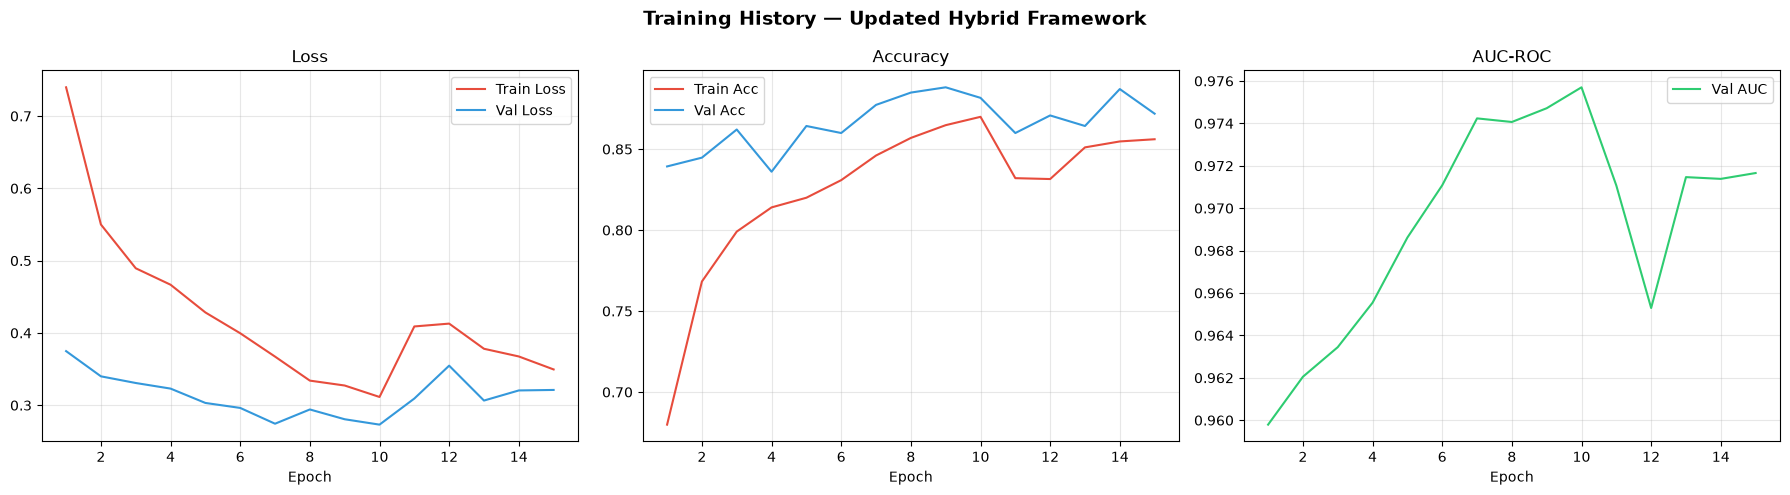

In [15]:
epochs_range = range(1, cfg.EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Updated Hybrid Framework', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#3498db')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', color='#e74c3c')
axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc',   color='#3498db')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

# AUC
axes[2].plot(epochs_range, history['val_auc'], label='Val AUC', color='#2ecc71')
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_curves.png'), dpi=150)
plt.show()

## 11. Test Set Evaluation

In [16]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=DEVICE))
model.eval()

@torch.no_grad()
def predict(model, loader, device):
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in tqdm(loader, desc='  Test', leave=False):
        imgs   = imgs.to(device)
        logits = model(imgs)
        # Keep the FULL per-class probability distribution (needed for
        # multiclass metrics below) instead of only class-1's probability.
        probs  = torch.softmax(logits.float(), dim=1).cpu().numpy()   # (B, num_classes)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

y_pred, y_prob, y_true = predict(model, test_loader, DEVICE)
# y_prob shape: (N, cfg.NUM_CLASSES)

# ── Metrics ───────────────────────────────────────────────────────────────────
# NUM_CLASSES = 4 now, so precision/recall/f1 need macro averaging, and AUC
# needs the full probability matrix with multi_class='ovr' (a plain 1-D
# y_prob only works for strictly binary problems).
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
auc  = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro') \
       if len(set(y_true.tolist())) > 1 else 0.0

print('=' * 55)
print('TEST SET PERFORMANCE — Updated Hybrid Framework')
print('=' * 55)
print(f'  Accuracy  : {acc  * 100:.2f}%')
print(f'  Precision (macro) : {prec:.4f}')
print(f'  Recall    (macro) : {rec:.4f}')
print(f'  F1-Score  (macro) : {f1:.4f}')
print(f'  AUC-ROC   (macro, OvR) : {auc:.4f}')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=cfg.CLASSES))


  Test:   0%|          | 0/29 [00:00<?, ?it/s]

TEST SET PERFORMANCE — Updated Hybrid Framework
  Accuracy  : 88.49%
  Precision (macro) : 0.8795
  Recall    (macro) : 0.8856
  F1-Score  (macro) : 0.8808
  AUC-ROC   (macro, OvR) : 0.9771
                     precision    recall  f1-score   support

           COVID-19       1.00      0.99      1.00       128
             Normal       0.96      0.99      0.98       327
Pneumonia-Bacterial       0.88      0.78      0.83       301
    Pneumonia-Viral       0.67      0.78      0.72       165

           accuracy                           0.88       921
          macro avg       0.88      0.89      0.88       921
       weighted avg       0.89      0.88      0.89       921



## 12. Confusion Matrix

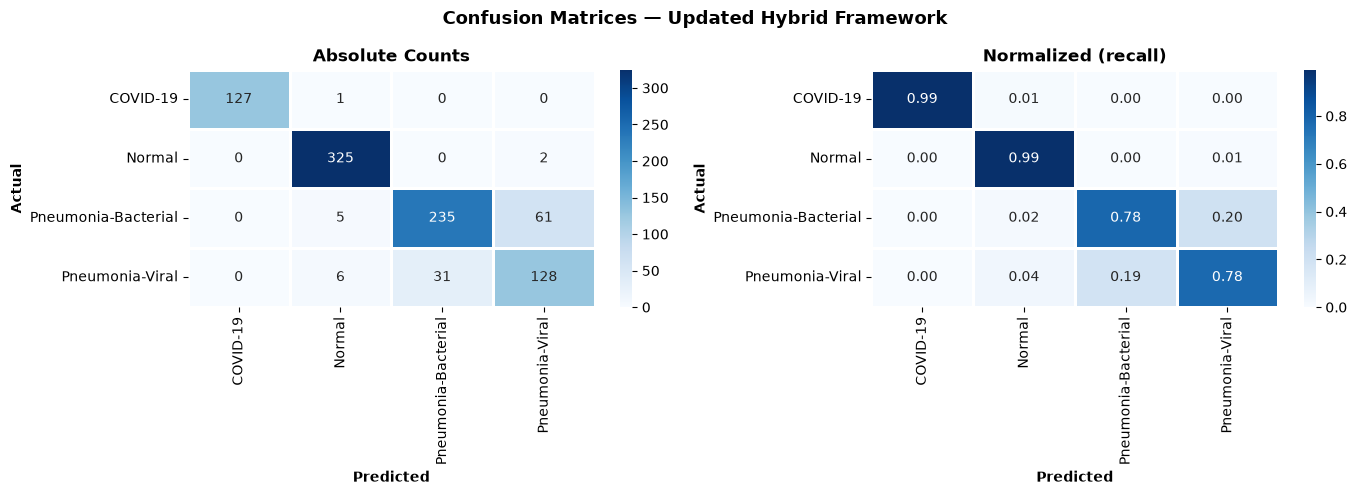

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Updated Hybrid Framework', fontsize=13, fontweight='bold')

for ax, norm, title in zip(axes,
                            [None, 'true'],
                            ['Absolute Counts', 'Normalized (recall)']):
    cm_plot = confusion_matrix(y_true, y_pred, normalize=norm)
    fmt = 'd' if norm is None else '.2f'
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=cfg.CLASSES, yticklabels=cfg.CLASSES,
                linewidths=1, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()

## 13. ROC Curve

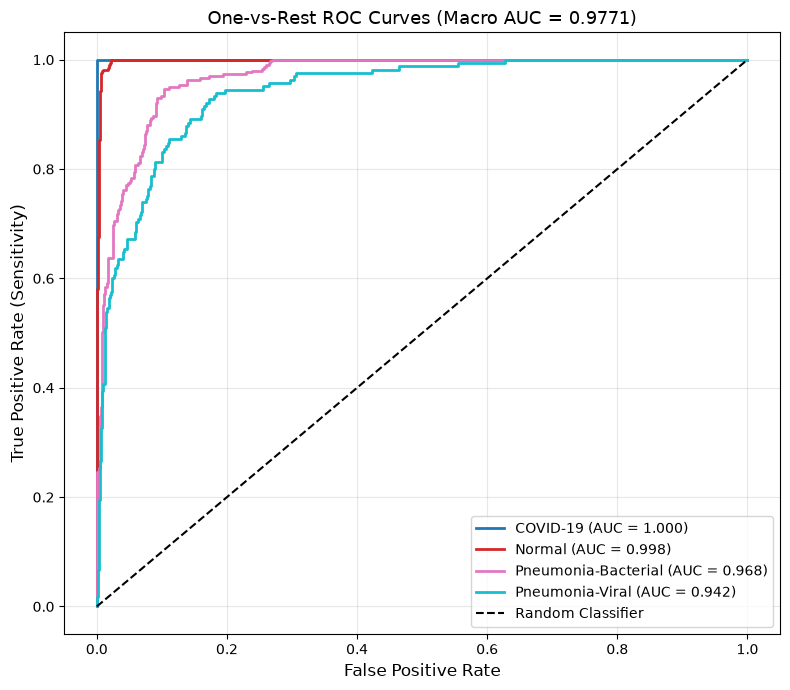

In [18]:
# ── One-vs-Rest ROC curves (multiclass) ───────────────────────────────────────
# y_prob is (N, cfg.NUM_CLASSES) now, so a single fpr/tpr pair (binary-style)
# no longer applies — plot one OvR curve per class instead.
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc as sk_auc

y_true_bin = label_binarize(y_true, classes=list(range(cfg.NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, cfg.NUM_CLASSES))

for i, cls_name in enumerate(cfg.CLASSES):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = sk_auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, lw=2, color=colors[i],
            label=f'{cls_name} (AUC = {class_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(f'One-vs-Rest ROC Curves (Macro AUC = {auc:.4f})', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'roc_curve.png'), dpi=150)
plt.show()


## 14. Performance Radar Chart

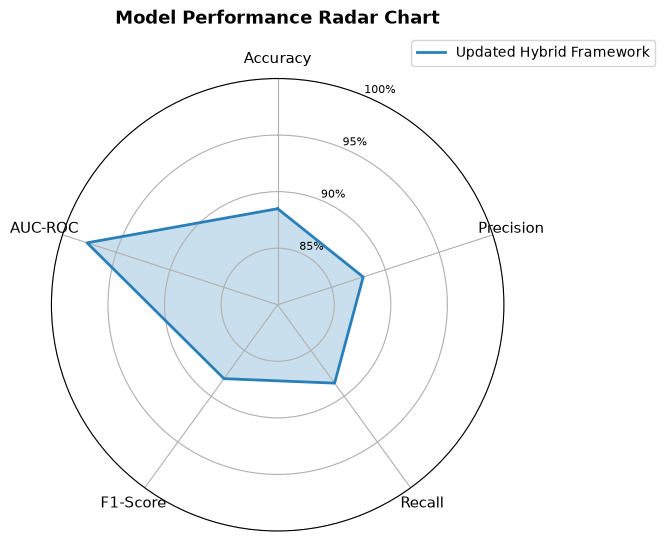

In [19]:
# ── Radar chart comparing key metrics ────────────────────────────────────────
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values         = [acc * 100, prec * 100, rec * 100, f1 * 100, auc * 100]

N = len(metrics_labels)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]    # close the polygon
values_plot = values + values[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_labels, fontsize=11)

ax.plot(angles, values_plot, linewidth=2, linestyle='solid',
        color='#2980b9', label='Updated Hybrid Framework')
ax.fill(angles, values_plot, alpha=0.25, color='#2980b9')

# Reference ring
ax.set_ylim(80, 100)
ax.set_yticks(range(80, 101, 5))
ax.set_yticklabels([f'{v}%' for v in range(80, 101, 5)], fontsize=8)

ax.set_title('Model Performance Radar Chart', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'radar_chart.png'), dpi=150)
plt.show()

## 15. Grad-CAM Visualization

IndexError: index 6 is out of bounds for axis 0 with size 6

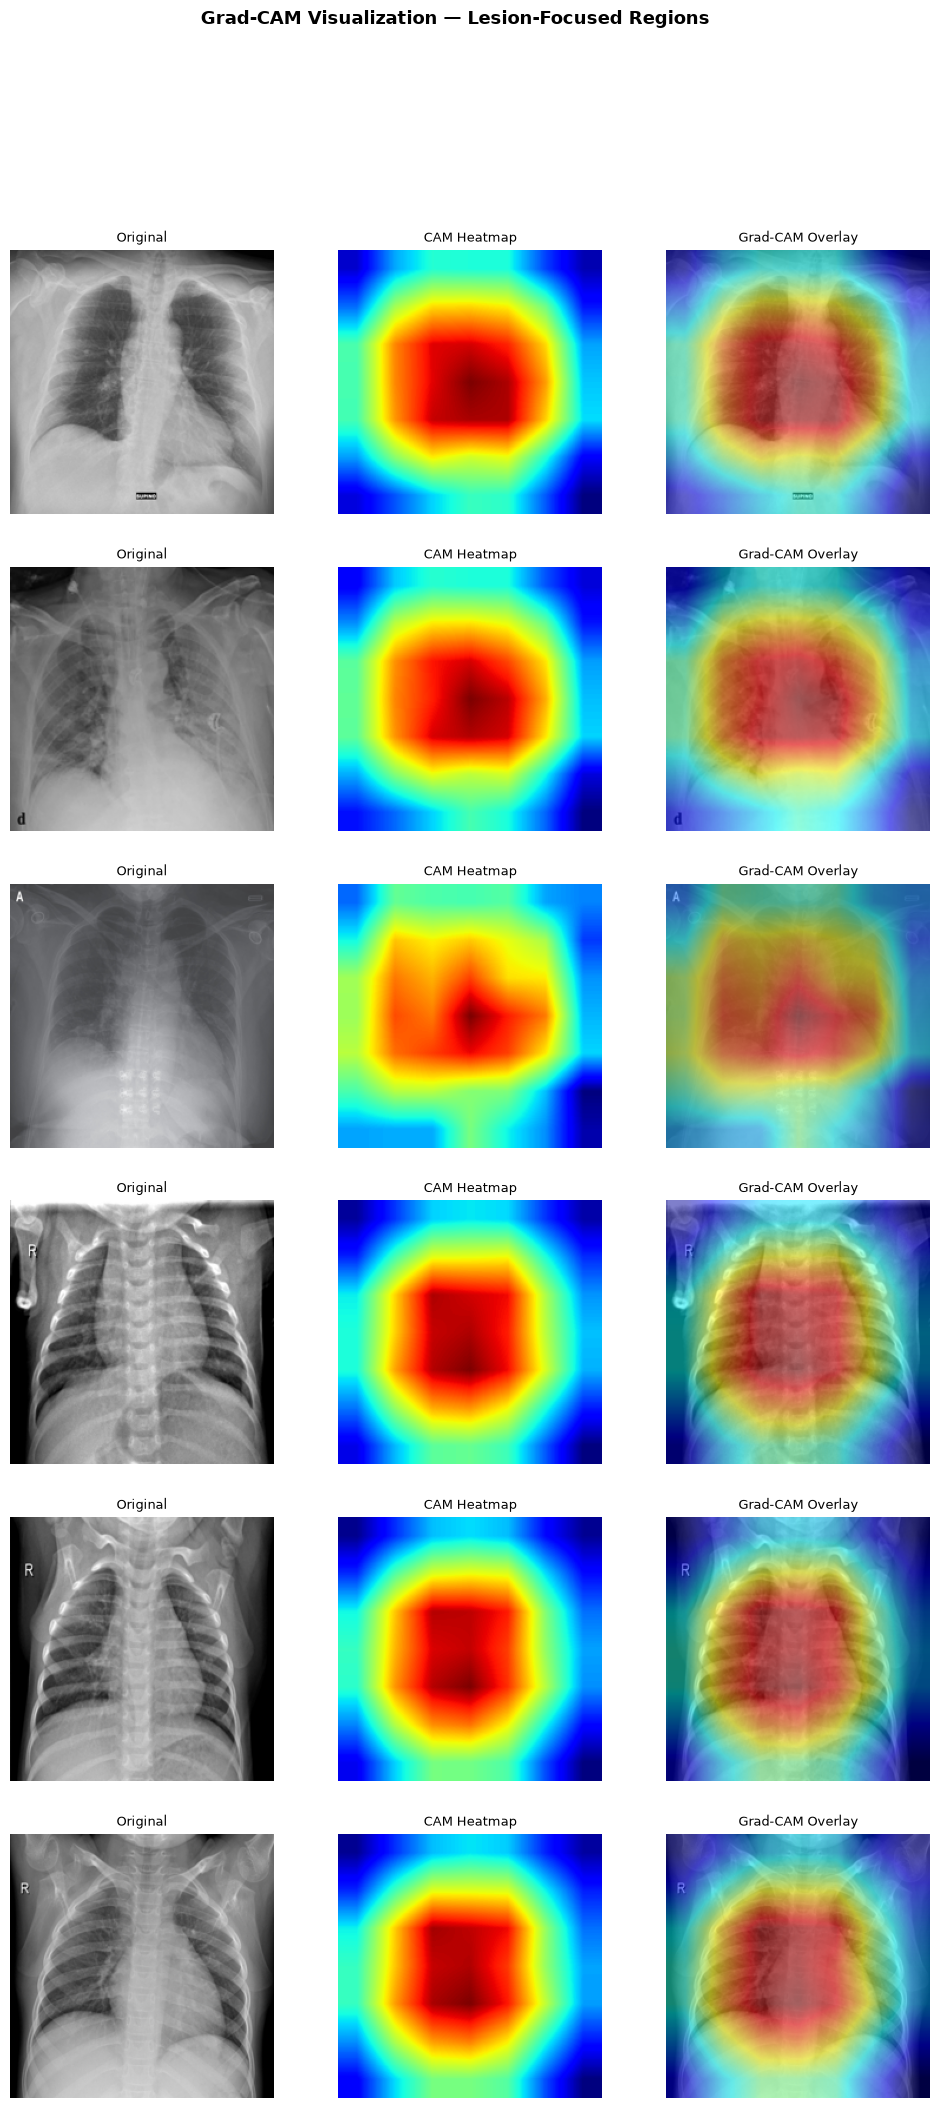

In [21]:
# ── Grad-CAM target layer = last conv in LAMR branch3 (5×5 kernel) ────────────
# This highlights lesion-focused spatial regions.
target_layer = model.lamr.branch5[-2]   # the last BN before ReLU in branch5

# Fallback: use last conv of LAMR proj
try:
    _ = target_layer.weight
except AttributeError:
    target_layer = model.lamr.proj[0]   # Conv2d in proj

cam = GradCAM(model=model, target_layers=[target_layer])


def show_gradcam(img_path: Path, label: int, ax_row, transforms_fn):
    """Draw original + Grad-CAM overlay for one image."""
    img_np  = np.array(Image.open(img_path).convert('RGB'))
    img_t   = transforms_fn(image=img_np)['image'].unsqueeze(0).to(DEVICE)

    # Resize for display
    img_resized = np.array(Image.fromarray(img_np).resize((224, 224))) / 255.0

    # Grad-CAM
    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=img_t, targets=targets)[0]
    cam_img = show_cam_on_image(img_resized.astype(np.float32),
                                 grayscale_cam, use_rgb=True)

    ax_row[0].imshow(img_resized); ax_row[0].set_title('Original', fontsize=9)
    ax_row[1].imshow(grayscale_cam, cmap='jet');
    ax_row[1].set_title('CAM Heatmap', fontsize=9)
    ax_row[2].imshow(cam_img);    ax_row[2].set_title('Grad-CAM Overlay', fontsize=9)
    for a in ax_row:
        a.axis('off')


# ── Pick 3 random samples per class ──────────────────────────────────────────
n_samples = 3
fig, axes = plt.subplots(2 * n_samples, 3, figsize=(12, 4 * n_samples * 2))
fig.suptitle('Grad-CAM Visualization — Lesion-Focused Regions', fontsize=13, fontweight='bold')

val_tf = get_val_transforms()
row = 0
for cls_idx, cls_name in enumerate(cfg.CLASSES):
    cls_samples = [(p, l) for p, l in test_dataset.samples if l == cls_idx]
    chosen      = random.sample(cls_samples, min(n_samples, len(cls_samples)))
    for path, lbl in chosen:
        axes[row, 0].set_ylabel(cls_name, fontsize=10, fontweight='bold',
                                color='green' if cls_idx == 0 else 'red')
        show_gradcam(path, lbl, axes[row], val_tf)
        row += 1

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'gradcam_visualization.png'), dpi=150)
plt.show()

## 16. Comparative Summary Table

In [22]:
# ── Comparison: original paper vs updated framework ───────────────────────────
comparison_data = {
    'Method': [
        'Original (VGG16 + ResNet + SVM)',
        'Original (VGG16 + ResNet + RF)',
        'Updated (ShuffleNetV2-ECA + EffNet-B0-CBAM + LAMR)'
    ],
    'Feature Extraction': [
        'VGG16 + ResNet (fused)',
        'VGG16 + ResNet (fused)',
        'ShuffleNetV2+ECA + EfficientNet-B0+CBAM'
    ],
    'Attention': [
        'None',
        'None',
        'ECA + CBAM + LAMR'
    ],
    'Classifier': [
        'SVM (RBF)',
        'Random Forest',
        'FC layers (end-to-end)'
    ],
    'Accuracy (%)': [
        '98.8',
        '95.8',
        f'{acc * 100:.2f}'
    ],
    'AUC-ROC': [
        '0.92',
        '0.92',
        f'{auc:.4f}'
    ],
    'Explainability': [
        'Interpretable (SVM)',
        'Interpretable (RF)',
        'Grad-CAM visual'
    ]
}

df = pd.DataFrame(comparison_data)
display(df)
df.to_csv(str(OUTPUT_DIR / 'comparison_table.csv'), index=False)
print('Comparison table saved.')

,Method,Feature Extraction,Attention,Classifier,Accuracy (%),AUC-ROC,Explainability
0,Original (VGG16 + ResNet + SVM),VGG16 + ResNet (fused),None,SVM (RBF),98.8,0.92,Interpretable (SVM)
1,Original (VGG16 + ResNet + RF),VGG16 + ResNet (fused),None,Random Forest,95.8,0.92,Interpretable (RF)
2,Updated (ShuffleNetV2-ECA + EffNet-B0-CBAM + L...,ShuffleNetV2+ECA + EfficientNet-B0+CBAM,ECA + CBAM + LAMR,FC layers (end-to-end),88.49,0.9771,Grad-CAM visual


Comparison table saved.


## 17. Performance Gap Heatmap

In [ ]:
# ── Performance gap (how far each model is from 100%) ─────────────────────────
models = ['SVM (original)', 'RF (original)', 'Updated Hybrid']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

# Fill in actual values (original from paper; updated from our test)
perf = np.array([
    [98.8, 99.0, 98.0, 98.0, 92.0],   # SVM original
    [95.8, 96.0, 94.0, 95.0, 92.0],   # RF  original
    [acc*100, prec*100, rec*100, f1*100, auc*100]   # Updated
])
gap = 100.0 - perf   # lower is better

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(gap, annot=perf, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=metrics, yticklabels=models,
            linewidths=0.5, ax=ax, vmin=0, vmax=15)
ax.set_title('Performance Gap Heatmap (Lower Gap = Better)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Metric', fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'performance_gap_heatmap.png'), dpi=150)
plt.show()

## 18. Architecture Diagram (Text Summary)

In [24]:
from torchinfo import summary

# Install torchinfo if needed
try:
    from torchinfo import summary
except ImportError:
    pip_install('torchinfo')
    from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'mult_adds'],
        depth=3)

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Mult-Adds
HybridPneumoniaNet                                           [1, 3, 224, 224]          [1, 4]                    --                        --
├─ShuffleNetV2_ECA: 1-1                                      [1, 3, 224, 224]          [1, 256]                  --                        --
│    └─Sequential: 2-1                                       [1, 3, 224, 224]          [1, 1024, 7, 7]           --                        --
│    │    └─Sequential: 3-1                                  [1, 3, 224, 224]          [1, 24, 112, 112]         696                       8,128,560
│    │    └─MaxPool2d: 3-2                                   [1, 24, 112, 112]         [1, 24, 56, 56]           --                        --
│    │    └─Sequential: 3-3                                  [1, 24, 56, 56]           [1, 116, 28, 28]          30,192               

## 19. Save Outputs

In [23]:
# ── Save final predictions ────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'true_label'     : y_true,
    'predicted_label': y_pred,
    'class_true'     : [cfg.CLASSES[l] for l in y_true],
    'class_pred'     : [cfg.CLASSES[l] for l in y_pred],
    'correct'        : y_true == y_pred
})
# y_prob is (N, num_classes) — add one probability column per class
for i, cls_name in enumerate(cfg.CLASSES):
    results_df[f'prob_{cls_name}'] = y_prob[:, i]

results_df.to_csv(str(OUTPUT_DIR / 'test_predictions.csv'), index=False)

# ── Save metrics summary ──────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'Accuracy' : round(acc, 4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec, 4),
    'F1-Score' : round(f1, 4),
    'AUC-ROC'  : round(auc, 4)
}])
metrics_df.to_csv(str(OUTPUT_DIR / 'metrics_summary.csv'), index=False)

print(f'All outputs saved to {OUTPUT_DIR}/')
print('\nFiles:')
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')


All outputs saved to /content/outputs/

Files:
  best_model.pth  (38565.0 KB)
  comparison_table.csv  (0.4 KB)
  confusion_matrix.png  (113.3 KB)
  metrics_summary.csv  (0.1 KB)
  radar_chart.png  (117.5 KB)
  roc_curve.png  (97.5 KB)
  sample_images.png  (2319.2 KB)
  test_predictions.csv  (76.1 KB)
  training_curves.png  (148.4 KB)
  training_state.pth  (115012.0 KB)


---
## Summary

| Component | Original Paper | This Update |
|-----------|---------------|-------------|
| Branch 1 | VGG16 | **ShuffleNetV2 + ECA** |
| Branch 2 | ResNet | **EfficientNet-B0 + CBAM** |
| Multi-scale module | — | **LAMR (1×1, 3×3, 5×5 parallel convs)** |
| Dimensionality reduction | PCA (100 components) | End-to-end via projection + pooling |
| Classifier | SVM / Random Forest | Fully-connected + Softmax |
| Interpretability | None | **Grad-CAM** |
| Parameters | ~140M+ | **~10–15M (lightweight)** |

**Key improvements:**
- ECA provides parameter-free channel attention that adaptively scales features with minimal overhead
- CBAM in EfficientNet-B0 adds channel + spatial attention jointly for discriminative global features
- LAMR module mirrors the HPFF + GCSAM multi-scale lesion awareness from nodule detection literature
- Grad-CAM provides visual explanations aligned with clinically relevant lung regions